In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 1. Install Unsloth & Dependencies
%%capture
!pip install --upgrade "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --upgrade unsloth-zoo
!pip install --no-deps "xformers<0.0.27" "trl<0.9.0" peft accelerate bitsandbytes

In [ ]:
# 2. Load Base Model
from unsloth import FastLanguageModel
import torch

max_seq_length = 2048
dtype = None
load_in_4bit = True

model_name = "iapp/chinda-qwen3-4b"

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = model_name,
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
)

# LoRA (Low-Rank Adaptation)
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",],
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
    use_rslora = False,
    loftq_config = None,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.2.1: Fast Qwen3 patching. Transformers: 4.57.6.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/3.08G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

...

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/613 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

Unsloth 2026.2.1 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


In [ ]:
# 3. Load & Format Data
from datasets import load_dataset

# Format Prompt
alpaca_prompt = """Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

### Instruction:
{}

### Input:
{}

### Response:
{}"""

EOS_TOKEN = tokenizer.eos_token

def formatting_prompts_func(examples):
    instructions = examples["instruction"]
    inputs       = examples["input"]
    outputs      = examples["output"]
    texts = []
    for instruction, input, output in zip(instructions, inputs, outputs):
        text = alpaca_prompt.format(instruction, input, output) + EOS_TOKEN
        texts.append(text)
    return { "text" : texts, }

# โหลดไฟล์ JSONL
dataset = load_dataset("json", data_files="/content/drive/MyDrive/Jenosize/jenosize_augmented.jsonl", split="train")
dataset = dataset.map(formatting_prompts_func, batched = True,)

Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/125 [00:00<?, ? examples/s]

In [ ]:
# 4. Train
from trl import SFTTrainer
from transformers import TrainingArguments

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    dataset_text_field = "text",
    max_seq_length = max_seq_length,
    dataset_num_proc = 2,
    packing = False,
    args=TrainingArguments(
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    warmup_steps=10,

    num_train_epochs=8,

    learning_rate=2e-5,
    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),
    logging_steps=1,
    optim="adamw_8bit",
    weight_decay=0.01,
    lr_scheduler_type="cosine",
    max_grad_norm=0.3,
    seed=3407,
    output_dir="outputs",
),
)

trainer.train()

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/125 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 125 | Num Epochs = 8 | Total steps = 64
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 8 x 1) = 16
 "-____-"     Trainable parameters = 33,030,144 of 4,055,498,240 (0.81% trained)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


wandb: Detected [huggingface_hub.inference, openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


Step,Training Loss
1,2.037800
2,1.925400
3,1.898100
4,1.895400
5,2.109100
6,2.108400
7,2.431900
8,2.074200
9,2.226600
10,2.127400


wandb: WARNING URL not available in offline run


train/epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇████
train/global_step,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇████
train/grad_norm,▄▄▄▄▄▄▄▄▅▃▆█▅▅▅▅▄▃▃▄▁▂▂▁▁▂▁▂▂▁▁▂▂▁▁▂▂▁▁▄
train/learning_rate,▂▃▄▅▆█████████▇▇▇▇▇▆▆▆▆▅▅▅▄▄▄▃▃▃▂▂▂▁▁▁▁▁
train/loss,▅▅▅▆▆▇▅█▅▄▃▅▄▆▆▄▆▃▃▃▁▃▂▆▅▃▆▃▄▄▅▄▃▂▃▄▂▂▄▃
total_flos,1.144473711542784e+16
train/epoch,8
train/global_step,64
train/grad_norm,0.3958
train/learning_rate,0.0
train/loss,1.6281


TrainOutput(global_step=64, training_loss=1.8473140243440866, metrics={'train_runtime': 895.782, 'train_samples_per_second': 1.116, 'train_steps_per_second': 0.071, 'total_flos': 1.144473711542784e+16, 'train_loss': 1.8473140243440866, 'epoch': 8.0})

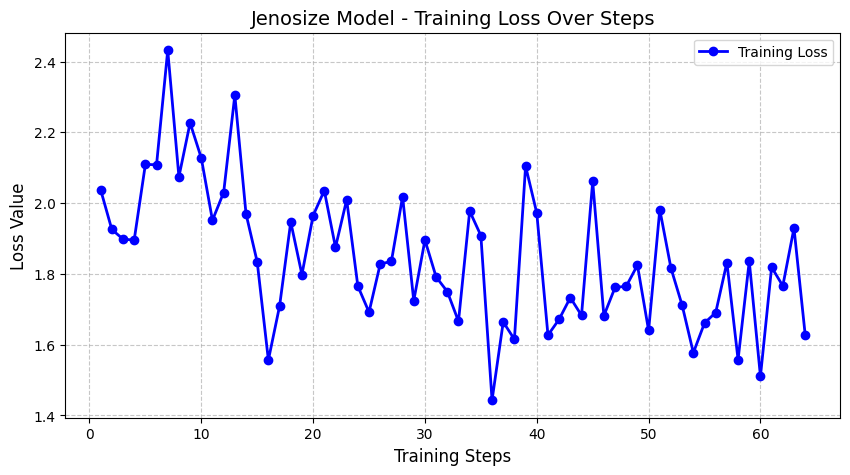

In [ ]:
import matplotlib.pyplot as plt

# ดึงประวัติการเทรนออกมาจาก Trainer
log_history = trainer.state.log_history
steps = [log["step"] for log in log_history if "loss" in log]
losses = [log["loss"] for log in log_history if "loss" in log]

# สั่งวาดกราฟ
plt.figure(figsize=(10, 5))
plt.plot(steps, losses, marker='o', linestyle='-', color='b', linewidth=2, label='Training Loss')
plt.title("Jenosize Model - Training Loss Over Steps", fontsize=14)
plt.xlabel("Training Steps", fontsize=12)
plt.ylabel("Loss Value", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
hf_token = "hf_"
hf_repo = "mix8645/jenosize-qwen3-4b"

print("🚀 Push to Hugging Face...")
model.push_to_hub(hf_repo, token=hf_token)
tokenizer.push_to_hub(hf_repo, token=hf_token)
print("✅ Done")

🚀 กำลังส่งโมเดลขึ้น Hugging Face...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   0%|          | 60.9kB /  132MB            

Saved model to https://huggingface.co/mix8645/jenosize-qwen3-4b


README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mplrbyroxp/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

✅ ส่งขึ้นยานแม่เรียบร้อย!
